# Step 1: Setup and MediaPipe (HandTracking)

MediaPipe: Fretting hand successfully selected! (Area: 1392336 px)
Hand Zone Bounding Box with Safety Padding: (1805, 869, 3129, 2143)


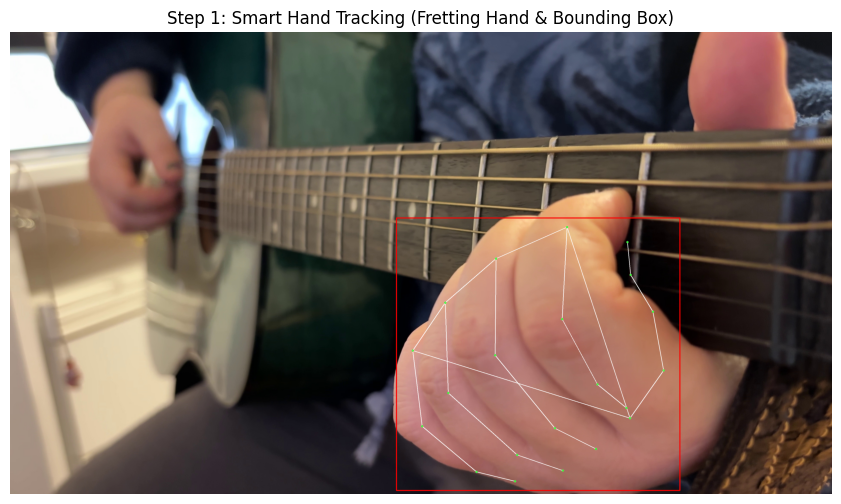

In [ ]:
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
# Test this with BOTH the "good" frame and the "bad" frame to ensure generalization!
image_path = "../data/processed_frames/A_01_seg2_A.jpg" # Update with your specific frame name

# 1. LOAD IMAGE
original_frame = cv2.imread(image_path)
if original_frame is None:
    # Try alternate path if running from a different root
    image_path = image_path.replace("../", "")
    original_frame = cv2.imread(image_path)

if original_frame is None:
    raise ValueError(f"Error loading image at: {image_path}")

frame_rgb = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
height, width, _ = frame_rgb.shape

# 2. MEDIAPIPE TRACKING (Generalization: Allow 2 hands, pick the largest)
# We still apply a soft crop on the left (15%) to avoid the body/picking hand, 
# but now we are robust even if it enters the frame.
crop_offset_x = int(width * 0.15)
soft_crop_img = frame_rgb[:, crop_offset_x:].copy()

mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=True, 
    max_num_hands=2,        # IMPORTANT: Look for multiple hands
    min_detection_confidence=0.1, 
    model_complexity=1
)
results = hands.process(soft_crop_img)

# 3. SMART HAND SELECTION (The Fretting Hand is closer = larger bounding box)
hand_zone = None
fretting_hand_landmarks = None
annotated_image = original_frame.copy()

if results.multi_hand_landmarks:
    max_area = 0
    cropped_width = width - crop_offset_x
    
    for hl in results.multi_hand_landmarks:
        # Map landmarks back to original image coordinates
        x_coords = [int(l.x * cropped_width) + crop_offset_x for l in hl.landmark]
        y_coords = [int(l.y * height) for l in hl.landmark]
        
        # Calculate Bounding Box Area
        area = (max(x_coords) - min(x_coords)) * (max(y_coords) - min(y_coords))
        
        if area > max_area:
            max_area = area
            fretting_hand_landmarks = hl
            
            # --- NEW: SAFETY PADDING ---
            # Aggiungiamo il 2% della larghezza/altezza per coprire la "carne" e le ombre
            pad_x = int(width * 0.02)
            pad_y = int(height * 0.02)
            
            hz_min_x = max(0, min(x_coords) - pad_x)
            hz_min_y = max(0, min(y_coords) - pad_y)
            hz_max_x = min(width, max(x_coords) + pad_x)
            hz_max_y = min(height, max(y_coords) + pad_y)
            
            hand_zone = (hz_min_x, hz_min_y, hz_max_x, hz_max_y)
    
    # Draw ONLY the selected fretting hand
    mp.solutions.drawing_utils.draw_landmarks(
        annotated_image[:, crop_offset_x:], 
        fretting_hand_landmarks, 
        mp_hands.HAND_CONNECTIONS,
        mp.solutions.drawing_utils.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=3),
        mp.solutions.drawing_utils.DrawingSpec(color=(255,255,255), thickness=2)
    )
    print(f"MediaPipe: Fretting hand successfully selected! (Area: {max_area} px)")
    
    # Draw the Bounding Box (Hand Zone) to visualize the "Dead Zone" in RED
    cv2.rectangle(annotated_image, (hand_zone[0], hand_zone[1]), (hand_zone[2], hand_zone[3]), (0, 0, 255), 3)
    print(f"Hand Zone Bounding Box with Safety Padding: {hand_zone}")

else:
    print("MediaPipe: Warning, no hands detected.")

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title('Step 1: Smart Hand Tracking (Fretting Hand & Bounding Box)')
plt.axis('off')
plt.show()

In [ ]:
# --- STEP 1 UPDATED: Smart Hand Selection ---
import cv2
import numpy as np
import mediapipe as mp
import matplotlib.pyplot as plt

# 1. LOAD IMAGE (A_01_seg2_C.jpg)
filename = "A_01_seg2_A.jpg" 
image_path = f"data/processed_frames/{filename}"
original_frame = cv2.imread(image_path)
if original_frame is None:
    original_frame = cv2.imread(f"../data/processed_frames/{filename}")

frame_rgb = cv2.cvtColor(original_frame, cv2.COLOR_BGR2RGB)
height, width, _ = frame_rgb.shape

# 2. MEDIAPIPE: Detect up to 2 hands
crop_offset_x = int(width * 0.15)
soft_crop_img = frame_rgb[:, crop_offset_x:].copy()

mp_hands = mp.solutions.hands
# Use max_num_hands=2
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=2, min_detection_confidence=0.1, model_complexity=1)
results = hands.process(soft_crop_img)

# 3. SELECT THE LARGEST HAND (Fretting Hand)
fretting_hand_landmarks = None
hand_zone = None

if results.multi_hand_landmarks:
    max_area = 0
    cropped_width = width - crop_offset_x
    
    for hl in results.multi_hand_landmarks:
        xc = [int(l.x * cropped_width) + crop_offset_x for l in hl.landmark]
        yc = [int(l.y * height) for l in hl.landmark]
        area = (max(xc) - min(xc)) * (max(yc) - min(yc))
        
        if area > max_area:
            max_area = area
            fretting_hand_landmarks = hl
            hand_zone = (min(xc), min(yc), max(xc), max(yc))
            # Store coordinates for following cells
            fretting_x_coords = xc
            fretting_y_coords = yc

# Visualization
annotated_image = original_frame.copy()
if fretting_hand_landmarks:
    mp.solutions.drawing_utils.draw_landmarks(
        annotated_image[:, crop_offset_x:], 
        fretting_hand_landmarks, 
        mp_hands.HAND_CONNECTIONS
    )
    print(f"MediaPipe: Selected Fretting Hand (Area: {max_area}px)")
else:
    print("MediaPipe: Warning, hand not detected.")

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(annotated_image, cv2.COLOR_BGR2RGB))
plt.title('Step 1: Selected Fretboard Hand')
plt.axis('off')
plt.show()

# Step 2: Sobel Y Preprocessing (Isolating Horizontal Edges)

In [ ]:
# 1. Convert original raw frame to grayscale
gray = cv2.cvtColor(original_frame, cv2.COLOR_BGR2GRAY)

# 2. Gaussian Blur to reduce high-frequency noise (sweater texture, wood grain)
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# 3. Sobel Y: The magic filter that highlights horizontal edges and kills vertical ones
sobel_y = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=3)
abs_sobel_y = cv2.convertScaleAbs(sobel_y)

# 4. Thresholding: Binarize the strongest horizontal edges
_, thresh_strings = cv2.threshold(abs_sobel_y, 40, 255, cv2.THRESH_BINARY)

# 5. Dilation: Thicken the lines slightly to repair small breaks
kernel = np.ones((3, 3), np.uint8)
preprocessed_strings = cv2.dilate(thresh_strings, kernel, iterations=1)

plt.figure(figsize=(10, 5))
plt.imshow(preprocessed_strings, cmap='gray')
plt.title('Step 2: Sobel Y Preprocessing (Horizontal Edges Only)')
plt.axis('off')
plt.show()

# Step 3: ROI (Noise and hand Removal)

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Create a fresh copy of the preprocessed image
roi_strings = preprocessed_strings.copy()

# 1. NOISE MASK: Black out the left 15% completely 
cv2.rectangle(roi_strings, (0, 0), (crop_offset_x, height), (0, 0, 0), -1)

# 2. ASYMMETRIC SURGICAL MASK (The Fingertip Killer)
if 'results' in locals() and results.multi_hand_landmarks:
    hand_landmarks = results.multi_hand_landmarks[0]
    cropped_width = width - crop_offset_x
    
    # Map coordinates back to full image scale
    x_coords = [int(l.x * cropped_width) + crop_offset_x for l in hand_landmarks.landmark]
    y_coords = [int(l.y * height) for l in hand_landmarks.landmark]
    
    # --- ASYMMETRIC PADDING ---
    padding_x = 5           # Keep sides tight to save horizontal string length
    padding_y_top = 180      # VERY GENEROUS ON TOP: Kill the fleshy fingertips!
    padding_y_bottom = 15   # A bit of safety margin on the bottom
    
    x_min = max(0, min(x_coords) - padding_x)
    x_max = min(width, max(x_coords) + padding_x)
    y_min = max(0, min(y_coords) - padding_y_top)
    y_max = min(height, max(y_coords) + padding_y_bottom)
    
    # Draw the surgical black box
    cv2.rectangle(roi_strings, (x_min, y_min), (x_max, y_max), (0, 0, 0), -1)
    print(f"Asymmetric mask applied. Y-Top extended by {padding_y_top} pixels.")

plt.figure(figsize=(10, 5))
plt.imshow(roi_strings, cmap='gray')
plt.title('Step 3: Asymmetric ROI (Fingertips Masked)')
plt.axis('off')
plt.show()

In [ ]:
# --- STEP 3 UPDATED: Using selected fretting hand ---
roi_strings = preprocessed_strings.copy()

# 1. NOISE MASK: Left 15%
cv2.rectangle(roi_strings, (0, 0), (crop_offset_x, height), (0, 0, 0), -1)

# 2. ASYMMETRIC ROI on the CORRECT hand
if fretting_hand_landmarks is not None:
    # Use the coordinates calculated in Step 1
    padding_x = 5
    padding_y_top = 180
    padding_y_bottom = 15
    
    x_min = max(0, min(fretting_x_coords) - padding_x)
    x_max = min(width, max(fretting_x_coords) + padding_x)
    y_min = max(0, min(fretting_y_coords) - padding_y_top)
    y_max = min(height, max(fretting_y_coords) + padding_y_bottom)
    
    cv2.rectangle(roi_strings, (x_min, y_min), (x_max, y_max), (0, 0, 0), -1)
    print(f"ROI applied to the correct hand at x={x_min}")

plt.figure(figsize=(10, 5))
plt.imshow(roi_strings, cmap='gray')
plt.title('Step 3: Corrected Asymmetric ROI')
plt.axis('off')
plt.show()

# Step 4 (Phase A): Hough Transform (String Extraction) 

In [ ]:
# Canvas for drawing the final lines
hough_strings_viz = original_frame.copy()

# Probabilistic Hough Transform optimized for long horizontal lines with gaps
lines_horizontal = cv2.HoughLinesP(
    roi_strings, 
    rho=1, 
    theta=np.pi/180, 
    threshold=35,       # Minimum votes
    minLineLength=40,   # Strings are long segments
    maxLineGap=150      # Jump over the surgical hand mask
)

raw_strings_data = [] # We will save these for the clustering phase

if lines_horizontal is not None:
    for line in lines_horizontal:
        x1, y1, x2, y2 = line[0]
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1 + 1e-6)))
        
        # Strict filter: keep only lines perfectly horizontal (+/- 8 degrees)
        if angle < 8 or angle > 172:
            cv2.line(hough_strings_viz, (x1, y1), (x2, y2), (0, 0, 255), 2) # RED
            raw_strings_data.append(line[0])

print(f"Extraction complete: Found {len(raw_strings_data)} raw string segments.")

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(hough_strings_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 4: Raw Strings Extracted (Ready for Math Clustering)')
plt.axis('off')
plt.show()

# Step 4 (Phase B) - Sobel X and ROI 

In [ ]:
# --- STEP 4: CUSTOM ROI FOR FRETS ---
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- PHASE B: FRET EXTRACTION ---

# 1. SOBEL X: The magic filter for VERTICAL edges
# We use the 'blurred' grayscale image from Step 2
sobel_x = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=3)
abs_sobel_x = cv2.convertScaleAbs(sobel_x)

# 2. Thresholding: Binarize the strongest vertical edges
_, thresh_frets = cv2.threshold(abs_sobel_x, 40, 255, cv2.THRESH_BINARY)

# 3. Vertical Dilation: Thicken the frets slightly to heal small breaks
# We use a vertical kernel (3 rows, 1 column) so we don't accidentally merge horizontal noise
kernel_v = np.ones((3, 1), np.uint8)
preprocessed_frets = cv2.dilate(thresh_frets, kernel_v, iterations=1)

# 1. Start with the Sobel X binarized image
roi_frets = preprocessed_frets.copy()
h, w = roi_frets.shape

# 2. NECK-ONLY MASK (Kill background noise)
# We only keep the horizontal band where the neck is likely to be
neck_top_limit = int(h * 0.25)
neck_bottom_limit = int(h * 0.75)
cv2.rectangle(roi_frets, (0, 0), (w, neck_top_limit), (0, 0, 0), -1)
cv2.rectangle(roi_frets, (0, neck_bottom_limit), (w, h), (0, 0, 0), -1)

# 3. PICKING HAND MASK
cv2.rectangle(roi_frets, (0, 0), (crop_offset_x, h), (0, 0, 0), -1)

# 4. INDEPENDENT HAND MASK FOR FRETS
if 'results' in locals() and results.multi_hand_landmarks:
    # Use the same base coordinates
    # But let's be LESS aggressive on top to see the fret metal above fingers
    padding_x_fret = 5
    padding_y_top_fret = 80    # Reduced from 180! We want to see the tips of the frets
    padding_y_bottom_fret = 20
    
    fx_min = max(0, min(x_coords) - padding_x_fret)
    fx_max = min(w, max(x_coords) + padding_x_fret)
    fy_min = max(0, min(y_coords) - padding_y_top_fret)
    fy_max = min(h, max(y_coords) + padding_y_bottom_fret)
    
    cv2.rectangle(roi_frets, (fx_min, fy_min), (fx_max, fy_max), (0, 0, 0), -1)
    print(f"Fret ROI applied with Top Padding: {padding_y_top_fret}")

plt.figure(figsize=(10, 5))
plt.imshow(roi_frets, cmap='gray')
plt.title('Step 5: Fret-Specific Surgical ROI')
plt.axis('off')
plt.show()

# Step 5: Fret Extraction 

In [ ]:
# --- STEP 5: REFINED FRET EXTRACTION (Anti-Noise & Length Filter) ---

hough_frets_viz = original_frame.copy()
neck_height = neck_bottom_limit - neck_top_limit

# We use the same parameters but we will filter the results in the loop
lines_vertical = cv2.HoughLinesP(
    roi_frets, 
    rho=1, 
    theta=np.pi/180, 
    threshold=25,       
    minLineLength=15,   # We keep it low to catch the "tips" above fingers
    maxLineGap=10
)

raw_frets_data = []

if lines_vertical is not None:
    for line in lines_vertical:
        x1, y1, x2, y2 = line[0]
        line_height = np.abs(y2 - y1)
        angle = np.abs(np.degrees(np.arctan2(y2 - y1, x2 - x1 + 1e-6)))
        
        # 1. STRICT VERTICAL FILTER
        if 82 < angle < 98:
            
            # 2. SMART LENGTH FILTER (The Anti-Dot Trap)
            # A real fret segment should be longer than a dot.
            # However, if it's near the fingers, it might be short.
            # We check if the line is NOT inside the hand area OR if it's long enough.
            
            is_near_hand = False
            if 'hand_zone' in locals() and hand_zone: # Using the hand_zone from the string step
                hx_min, hy_min, hx_max, hy_max = hand_zone
                is_near_hand = (hx_min - 20 < x1 < hx_max + 20)
            
            # If it's far from the hand, it MUST be at least 30% of the neck height
            # If it's near the hand, we accept it even if shorter (to catch the "tip" of the fret)
            min_allowed_height = neck_height * 0.3 if not is_near_hand else 10
            
            if line_height > min_allowed_height:
                cv2.line(hough_frets_viz, (x1, y1), (x2, y2), (255, 0, 0), 2) # BLUE
                raw_frets_data.append(line[0])

print(f"Fret extraction complete: Found {len(raw_frets_data)} valid segments.")

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(hough_frets_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 5 Final: Frets with Length Filter (Dots Removed)')
plt.axis('off')
plt.show()

# Step 6: Unified Visualization

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 6: MASTER UNIFIED VISUALIZATION ---

# 1. Create a clean canvas from the original color frame
final_viz = original_frame.copy()

# 2. DRAW STRINGS (From Phase A)
# We use the raw_strings_data list we populated in Step 4
if 'raw_strings_data' in locals() and raw_strings_data:
    for line in raw_strings_data:
        x1, y1, x2, y2 = line
        cv2.line(final_viz, (x1, y1), (x2, y2), (0, 0, 255), 2) # RED for Strings

# 3. DRAW FRETS (From Phase B)
# We use the raw_frets_data list we populated in Step 6
if 'raw_frets_data' in locals() and raw_frets_data:
    for line in raw_frets_data:
        x1, y1, x2, y2 = line
        cv2.line(final_viz, (x1, y1), (x2, y2), (255, 0, 0), 2) # BLUE for Frets

# 4. DRAW HAND LANDMARKS (MediaPipe)
# This adds the context of WHERE the fingers are relative to our grid
if 'results' in locals() and results.multi_hand_landmarks:
    import mediapipe as mp
    mp_drawing = mp.solutions.drawing_utils
    mp_hands = mp.solutions.hands
    
    # We need to draw on the soft_crop area or map back to full frame
    # For simplicity, we'll draw the landmarks directly using the hand_zone logic
    for hand_landmarks in results.multi_hand_landmarks:
        # Drawing connections to see the hand structure
        mp_drawing.draw_landmarks(
            final_viz[:, crop_offset_x:], # Draw on the right portion
            hand_landmarks, 
            mp_hands.HAND_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2), # Green points
            mp_drawing.DrawingSpec(color=(255,255,255), thickness=2) # White lines
        )

# 5. PRINT SUMMARY
print(f"--- Day 2 Extraction Summary ---")
print(f"Strings segments found: {len(raw_strings_data) if 'raw_strings_data' in locals() else 0}")
print(f"Frets segments found: {len(raw_frets_data) if 'raw_frets_data' in locals() else 0}")
print(f"Hand Tracking: {'ACTIVE' if results.multi_hand_landmarks else 'NOT FOUND'}")

# 6. FINAL DISPLAY
plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(final_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 6: Unified Raw Grid (Strings, Frets & Hand)')
plt.axis('off')
plt.show()

# Step 7: String Merging (Linear Regression)

In [ ]:
# --- STEP 7 REVISED: STRING CLUSTERING WITH LINEAR REGRESSION ---

def cluster_strings_with_tilt(segments, threshold=12):
    if not segments:
        return []
    
    # 1. Calculate midpoint Y for initial clustering
    y_midpoints = [(seg[1] + seg[3]) / 2 for seg in segments]
    combined = sorted(zip(y_midpoints, segments), key=lambda x: x[0])
    
    clusters = []
    if combined:
        current_cluster = [combined[0][1]]
        for i in range(1, len(combined)):
            if abs(combined[i][0] - combined[i-1][0]) <= threshold:
                current_cluster.append(combined[i][1])
            else:
                clusters.append(current_cluster)
                current_cluster = [combined[i][1]]
        clusters.append(current_cluster)
        
    merged_lines = []
    for cluster in clusters:
        # Collect all points (x1, y1) and (x2, y2) from all segments in the cluster
        all_x = []
        all_y = []
        for seg in cluster:
            all_x.extend([seg[0], seg[2]])
            all_y.extend([seg[1], seg[3]])
        
        # 2. LINEAR REGRESSION: Find the best fit line (y = mx + q)
        # np.polyfit(x, y, 1) returns [slope, intercept]
        slope, intercept = np.polyfit(all_x, all_y, 1)
        
        # Determine the full length based on the cluster's span
        x_min = min(all_x)
        x_max = max(all_x)
        
        # 3. Calculate start and end Y based on the REAL slope
        y_start = int(slope * x_min + intercept)
        y_end = int(slope * x_max + intercept)
        
        merged_lines.append([x_min, y_start, x_max, y_end])
    
    return merged_lines

# Execute the new tilted clustering
merged_strings = cluster_strings_with_tilt(raw_strings_data, threshold=12)

# Visualization
clustering_viz = original_frame.copy()
for line in merged_strings:
    # Use a thinner line (thickness=2) to see if it perfectly aligns with the red ones
    cv2.line(clustering_viz, (line[0], line[1]), (line[2], line[3]), (0, 255, 0), 2)

print(f"Clustering complete: Merged {len(raw_strings_data)} segments into {len(merged_strings)} tilted strings.")

plt.figure(figsize=(10, 7))
plt.imshow(cv2.cvtColor(clustering_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 7 Final: String Clustering (With Perspective & Tilt)')
plt.axis('off')
plt.show()

# Step 8: Global Geometric Reconstruction

## 8.1 String reconstruction

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 8.1: VANISHING POINT GEOMETRIC RECONSTRUCTION ---

reconstruction_viz = original_frame.copy()
h, w, _ = original_frame.shape
center_x = w // 2

# 1. EXTRACT LONG LINES (Eliminating noise, keeping only the solid ones)
long_lines_data = []
for line in merged_strings:
    x1, y1, x2, y2 = line
    if x1 == x2: continue
    
    length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    # We only keep lines longer than 35% of the screen.
    # This automatically discards noise, the broken 3rd string, and the short 4th string!
    if length > w * 0.35: 
        m = (y2 - y1) / (x2 - x1)
        q = y1 - m * x1
        y_c = m * center_x + q
        long_lines_data.append({'m': m, 'q': q, 'y_c': y_c})

# Sort lines from top to bottom
long_lines_data.sort(key=lambda x: x['y_c'])

# 2. THE PERSPECTIVE ENGINE (Using ONLY String 1 and String 2)
if len(long_lines_data) >= 3:
    # index 0: Neck edge (Ignored)
    # index 1: 1st String (Anchor 1)
    # index 2: 2nd String (Anchor 2)
    
    str1 = long_lines_data[1]
    str2 = long_lines_data[2]
    
    m1, q1 = str1['m'], str1['q']
    m2, q2 = str2['m'], str2['q']
    
    # Calculate the Vanishing Point (Intersection of String 1 and String 2)
    # Equation: m1*x + q1 = m2*x + q2
    if abs(m1 - m2) > 1e-6: # Prevent division by zero if they are perfectly parallel
        v_x = (q2 - q1) / (m1 - m2)
        v_y = m1 * v_x + q1
    else:
        v_x = -1000000 # Parallel lines meet at infinity
        v_y = str1['y_c']
        
    # Calculate the GAP at the FAR RIGHT edge of the screen (x = w)
    # This is near the nut, where the strings appear widest.
    y1_right = m1 * w + q1
    y2_right = m2 * w + q2
    gap_right = y2_right - y1_right
    
    print("--- Perspective Math (Vanishing Point) ---")
    print(f"- Vanishing Point (Vx, Vy): ({int(v_x)}, {int(v_y)})")
    print(f"- Reference Gap at Nut (Right side): {gap_right:.2f} px")

    # 3. GENERATE ALL 6 STRINGS
    final_6_strings = []
    
    for i in range(6):
        # Calculate the Y coordinate of this string at the right edge
        target_y_right = y1_right + (i * gap_right)
        
        # We need a line that passes through (v_x, v_y) and (w, target_y_right)
        m_new = (target_y_right - v_y) / (w - v_x)
        q_new = target_y_right - (m_new * w)
        
        # Find coordinates for the left edge of the screen (x = 0)
        y_start = int(q_new)
        y_end = int(target_y_right)
        
        final_6_strings.append([0, y_start, w, y_end])
        
        # Draw the generated strings in MAGENTA
        cv2.line(reconstruction_viz, (0, y_start), (w, y_end), (255, 0, 255), 3)

else:
    print("ERROR: Not enough long lines found to calculate perspective.")

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(reconstruction_viz, cv2.COLOR_BGR2RGB))
plt.title("Step 8.1: Vanishing Point Reconstruction (From User Logic)")
plt.axis('off')
plt.show()

## 8.2 Fret Reconstruction 

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 9.2: FRET GEOMETRIC RECONSTRUCTION (Perspective Growth) ---

reconstruction_frets_viz = original_frame.copy()
h, w, _ = original_frame.shape

# 1. CLUSTERING FRETS BY X-COORDINATE
fret_segments = []
for x1, y1, x2, y2 in raw_frets_data:
    x_c = (x1 + x2) / 2
    fret_segments.append({'x_c': x_c, 'x1': x1, 'y1': y1, 'x2': x2, 'y2': y2})

fret_segments.sort(key=lambda item: item['x_c'])

clusters = []
if fret_segments:
    current_cluster = [fret_segments[0]]
    for i in range(1, len(fret_segments)):
        if fret_segments[i]['x_c'] - fret_segments[i-1]['x_c'] < 15:
            current_cluster.append(fret_segments[i])
        else:
            clusters.append(current_cluster)
            current_cluster = [fret_segments[i]]
    clusters.append(current_cluster)

# 2. MERGING AND CALCULATING TILT (Linear Regression)
clean_frets = []
for cluster in clusters:
    y_pts = []
    x_pts = []
    for seg in cluster:
        y_pts.extend([seg['y1'], seg['y2']])
        x_pts.extend([seg['x1'], seg['x2']])

    if len(y_pts) > 1:
        coeffs = np.polyfit(y_pts, x_pts, 1)
        m_inv = coeffs[0]  
        q_inv = coeffs[1]  
        
        x_center = m_inv * (h / 2) + q_inv
        clean_frets.append({'m_inv': m_inv, 'q_inv': q_inv, 'x_c': x_center})

clean_frets.sort(key=lambda item: item['x_c'])

# 3. DYNAMIC NUT RECONSTRUCTION (Perspective + Guitar Physics)
if len(clean_frets) >= 3:
    x_centers = [f['x_c'] for f in clean_frets]
    gaps = np.diff(x_centers) # These are the gaps from left to right
    
    # Calculate how much the gap GROWS as we move right towards the camera
    ratios = [gaps[i] / gaps[i-1] for i in range(1, len(gaps))]
    
    # Average growth factor (Guitar physics = ~1.06, but perspective makes it much larger)
    growth_factor = np.mean(ratios) if ratios else 1.3
    
    # Safety clamp to prevent crazy jumps (usually between 1.2x and 1.6x due to perspective)
    growth_factor = max(1.15, min(growth_factor, 1.8))
    
    last_gap = gaps[-1]
    nut_gap = last_gap * growth_factor # Exponentially larger gap for the nut
    
    right_fret = clean_frets[-1]
    estimated_nut_x_c = right_fret['x_c'] + nut_gap
    
    print("--- Perspective Nut Math ---")
    print(f"- Last fret gap: {last_gap:.2f} px")
    print(f"- Perspective growth factor: {growth_factor:.2f}x")
    print(f"- Calculated Nut gap: {nut_gap:.2f} px")
    
    clean_frets.append({
        'm_inv': right_fret['m_inv'],
        'q_inv': estimated_nut_x_c - (right_fret['m_inv'] * (h / 2)),
        'x_c': estimated_nut_x_c,
        'is_nut': True 
    })

# 4. DRAWING BOUNDED BY STRINGS
str1 = final_6_strings[0] 
str6 = final_6_strings[5] 

m_str1 = (str1[3] - str1[1]) / w  
q_str1 = str1[1]

m_str6 = (str6[3] - str6[1]) / w
q_str6 = str6[1]

final_frets_lines = []

for f in clean_frets:
    m_f = f['m_inv']
    q_f = f['q_inv']
    
    # Intersection with String 1
    denominator_top = 1 - (m_f * m_str1)
    if abs(denominator_top) > 1e-6:
        x_top = (m_f * q_str1 + q_f) / denominator_top
        y_top = m_str1 * x_top + q_str1
    else:
        x_top, y_top = f['x_c'], q_str1 
        
    # Intersection with String 6
    denominator_bottom = 1 - (m_f * m_str6)
    if abs(denominator_bottom) > 1e-6:
        x_bottom = (m_f * q_str6 + q_f) / denominator_bottom
        y_bottom = m_str6 * x_bottom + q_str6
    else:
        x_bottom, y_bottom = f['x_c'], q_str6 
        
    color = (0, 255, 255) if f.get('is_nut') else (0, 255, 0) 
    pt1 = (int(x_top), int(y_top))
    pt2 = (int(x_bottom), int(y_bottom))
    
    cv2.line(reconstruction_frets_viz, pt1, pt2, color, 3)
    final_frets_lines.append([pt1[0], pt1[1], pt2[0], pt2[1]])

plt.figure(figsize=(12, 7))
plt.imshow(cv2.cvtColor(reconstruction_frets_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 8.2: Frets & Exponential Nut Reconstruction')
plt.axis('off')
plt.show()

# Step 9: Fretboard Matrix

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- STEP 9: FRETBOARD GRID GENERATION (The Matrix) ---

grid_viz = original_frame.copy()

# Helper function to find the exact intersection of two mathematical lines
def get_intersection(line1, line2):
    x1, y1, x2, y2 = line1
    x3, y3, x4, y4 = line2

    # Determinant formula for line intersection
    denom = (x1 - x2) * (y3 - y4) - (y1 - y2) * (x3 - x4)
    if denom == 0:
        return None # Lines are perfectly parallel (shouldn't happen here)

    px = ((x1 * y2 - y1 * x2) * (x3 - x4) - (x1 - x2) * (x3 * y4 - y3 * x4)) / denom
    py = ((x1 * y2 - y1 * x2) * (y3 - y4) - (y1 - y2) * (x3 * y4 - y3 * x4)) / denom
    
    return (int(px), int(py))

# 1. INITIALIZE THE MATRIX
# We will create a 2D array (list of lists) to store the coordinate of every node.
# fretboard_matrix[fret_index][string_index] = (x, y)
fretboard_matrix = []

print("--- Generating Fretboard Matrix ---")

# 2. CALCULATE INTERSECTIONS
# Loop through each fret (from left to right)
for fret_idx, fret_line in enumerate(final_frets_lines):
    current_fret_nodes = []
    
    # Loop through each string (from top to bottom, 1st to 6th)
    for string_idx, string_line in enumerate(final_6_strings):
        
        # Calculate where this specific string crosses this specific fret
        node_coords = get_intersection(fret_line, string_line)
        
        if node_coords:
            current_fret_nodes.append(node_coords)
            
            # Draw the node on our visualization image
            # Yellow for the Nut (last fret in our list), Red for normal frets
            is_nut = (fret_idx == len(final_frets_lines) - 1)
            dot_color = (0, 255, 255) if is_nut else (0, 0, 255)
            
            # Draw a circle at the intersection
            cv2.circle(grid_viz, node_coords, 5, dot_color, -1)

    # Add the column of 6 nodes to our main matrix
    fretboard_matrix.append(current_fret_nodes)

# 3. DRAW THE GRID LINES (For final visual confirmation)
# Draw Strings (Magenta)
for s in final_6_strings:
    cv2.line(grid_viz, (int(s[0]), int(s[1])), (int(s[2]), int(s[3])), (255, 0, 255), 2)

# Draw Frets (Cyan)
for f in final_frets_lines:
    cv2.line(grid_viz, (int(f[0]), int(f[1])), (int(f[2]), int(f[3])), (255, 255, 0), 2)

print(f"Matrix successfully generated: {len(fretboard_matrix)} Frets x {len(fretboard_matrix[0])} Strings.")

# 4. SHOW THE MASTERPIECE
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(grid_viz, cv2.COLOR_BGR2RGB))
plt.title('Step 9: Final Fretboard Matrix (Intersection Nodes)')
plt.axis('off')
plt.show()